In [2]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
import time

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
initial = lambda x,y: 1 * np.sin(np.pi * x) * 1 * np.sin(np.pi * y)

h_x = 1/20
h_y = 1/20
h_t = 1/50
alpha = 1

x = np.linspace(0,1,int(1/h_x) + 1)
y = np.linspace(0,1,int(1/h_y) + 1)
t_vals = np.linspace(0,.05,int(1/h_t) + 1)

X,Y = np.meshgrid(x,y)

A_1 = alpha/(h_x**2) * (np.diag(np.ones_like(x)[1:], k = -1) + np.diag(np.ones_like(x) * -2, k = 0) + np.diag(np.ones_like(x)[1:], k = 1))
A_2 = alpha/(h_y**2) * (np.diag(np.ones_like(y)[1:], k = -1) + np.diag(np.ones_like(y) * -2, k = 0) + np.diag(np.ones_like(y)[1:], k = 1))

B_top1 = (np.diag(1 * np.ones_like(y)[1:]/h_x, k = -1) + np.diag(np.ones_like(y) * 2 * (1 - 1/h_x), k = 0) + np.diag(np.ones_like(y)[1:]/h_x, k = 1))[1:-1,1:-1]/4
B_top2 = (np.diag(-1 * np.ones_like(y)[1:]/h_x, k = -1) + np.diag(np.ones_like(y) * 2 * (1 + 1/h_x), k = 0) + np.diag(-np.ones_like(y)[1:]/h_x, k = 1))[1:-1,1:-1]/4

U_pred = [initial(X,Y)]

for t in t_vals[1:]:
  v_half = np.ones_like(U_pred[-1])
  v_half[1:-1,1:-1] = np.linalg.solve(np.eye(len(A_1)-2) - h_t/2 * A_1[1:-1, 1:-1], ((np.eye(len(A_2) - 2) + h_t/2 * A_2[1:-1,1:-1]) @ U_pred[-1][1:-1,1:-1]).T).T

  # v_half[0,1:-1] = B_top1 @ u_true(t - h_t, X[0,1:-1], Y[0,1:-1]) + B_top2 @ u_true(t, X[0,1:-1], Y[0,1:-1])
  # v_half[-1,1:-1] = B_top1 @ u_true(t - h_t, X[-1,1:-1], Y[-1,1:-1]) + B_top2 @ u_true(t, X[-1,1:-1], Y[-1,1:-1])
  v_half[0,1:-1] = 0
  v_half[-1,1:-1] = 0

  v = np.ones_like(U_pred[-1])
  v[1:-1,1:-1] = np.linalg.solve(np.eye(len(A_2) - 2) - h_t/2 * A_2[1:-1, 1:-1], ((np.eye(len(A_1) - 2) + h_t/2 * A_1[1:-1, 1:-1]) @ v_half[1:-1,1:-1].T).T)

  # Set boundary conditions
  v[0,:] = 0
  v[-1,:] = 0
  v[1:-1,0] = 0
  v[1:-1,-1] = 0

  # Save time step
  U_pred.append(v)

  
# Create 3D plot
fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111, projection='3d')

ax1.set_zlim3d([-1.1,1.1])

# Create empty line objects
pred = ax1.plot_surface(X, Y, U_pred[0], cmap = 'inferno')

ax1.set_title('Predicted Solution')



# Make update function to updata all line plots
def update(t):
    global true, pred

    pred.remove()

    pred = ax1.plot_surface(X, Y, U_pred[t], cmap='inferno', vmax = np.max(U_pred), vmin = np.min(U_pred))

    return pred


# Make figure
ani = FuncAnimation(fig, update, frames=range(len(t_vals)), interval=40)
ani.save(f'ADI_heat_solution.mp4')

plt.close()




In [11]:
def convergence_experiment(h_x, h_y, h_t, plot = False):
    initial = lambda x,y: 1 * np.sin(np.pi * x) * 1 * np.sin(np.pi * y)
    truth = lambda X, Y, t: np.exp(-2 * np.pi**2 * alpha * t) * np.sin(np.pi * X) * np.sin(np.pi * Y)
    
    alpha = 1

    x = np.linspace(0,1,int(1/h_x) + 1)
    y = np.linspace(0,1,int(1/h_y) + 1)
    t_vals = np.linspace(0,1,int(1/h_t) + 1)

    X,Y = np.meshgrid(x,y)

    A_1 = alpha/(h_x**2) * (np.diag(np.ones_like(x)[1:], k = -1) + np.diag(np.ones_like(x) * -2, k = 0) + np.diag(np.ones_like(x)[1:], k = 1))
    A_2 = alpha/(h_y**2) * (np.diag(np.ones_like(y)[1:], k = -1) + np.diag(np.ones_like(y) * -2, k = 0) + np.diag(np.ones_like(y)[1:], k = 1))

    B_top1 = (np.diag(1 * np.ones_like(y)[1:]/h_x, k = -1) + np.diag(np.ones_like(y) * 2 * (1 - 1/h_x), k = 0) + np.diag(np.ones_like(y)[1:]/h_x, k = 1))[1:-1,1:-1]/4
    B_top2 = (np.diag(-1 * np.ones_like(y)[1:]/h_x, k = -1) + np.diag(np.ones_like(y) * 2 * (1 + 1/h_x), k = 0) + np.diag(-np.ones_like(y)[1:]/h_x, k = 1))[1:-1,1:-1]/4

    U_pred = [initial(X,Y)]
    start = time.time()
    for t in t_vals[1:]:
        v_half = np.ones_like(U_pred[-1])
        v_half[1:-1,1:-1] = np.linalg.solve(np.eye(len(A_1)-2) - h_t/2 * A_1[1:-1, 1:-1], ((np.eye(len(A_2) - 2) + h_t/2 * A_2[1:-1,1:-1]) @ U_pred[-1][1:-1,1:-1]).T).T

        # v_half[0,1:-1] = B_top1 @ u_true(t - h_t, X[0,1:-1], Y[0,1:-1]) + B_top2 @ u_true(t, X[0,1:-1], Y[0,1:-1])
        # v_half[-1,1:-1] = B_top1 @ u_true(t - h_t, X[-1,1:-1], Y[-1,1:-1]) + B_top2 @ u_true(t, X[-1,1:-1], Y[-1,1:-1])
        v_half[0,1:-1] = 0
        v_half[-1,1:-1] = 0

        v = np.ones_like(U_pred[-1])
        v[1:-1,1:-1] = np.linalg.solve(np.eye(len(A_2) - 2) - h_t/2 * A_2[1:-1, 1:-1], ((np.eye(len(A_1) - 2) + h_t/2 * A_1[1:-1, 1:-1]) @ v_half[1:-1,1:-1].T).T)

        # Set boundary conditions
        v[0,:] = 0
        v[-1,:] = 0
        v[1:-1,0] = 0
        v[1:-1,-1] = 0

        # Save time step
        U_pred.append(v)
    
    end_time = time.time() - start

    
    if plot == True:
        # Create 3D plot
        fig = plt.figure(figsize=(8,6))
        ax1 = fig.add_subplot(111, projection='3d')

        ax1.set_zlim3d([-1.1,1.1])

        # Create empty line objects
        pred = ax1.plot_surface(X, Y, U_pred[0], cmap = 'inferno')

        ax1.set_title('Predicted Solution')
        # Make update function to updata all line plots
        def update(t):
            global true, pred

            pred.remove()

            pred = ax1.plot_surface(X, Y, U_pred[t], cmap='inferno', vmax = np.max(U_pred), vmin = np.min(U_pred))

            return pred


        # Make figure
        ani = FuncAnimation(fig, update, frames=range(len(t_vals)), interval=40)
        ani.save(f'solution.mp4')

        plt.close()

    return np.linalg.norm(U_pred[-1] - truth(X,Y,t)), end_time




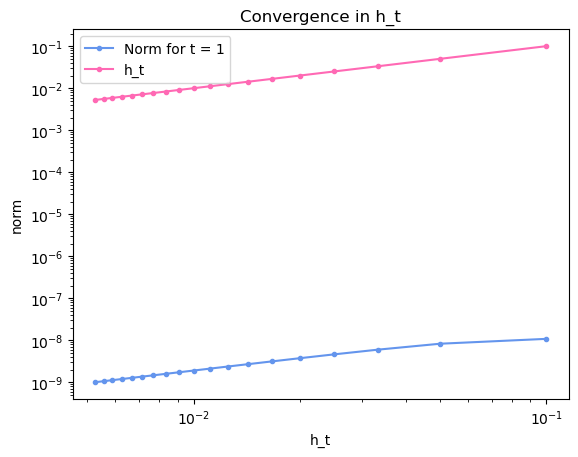

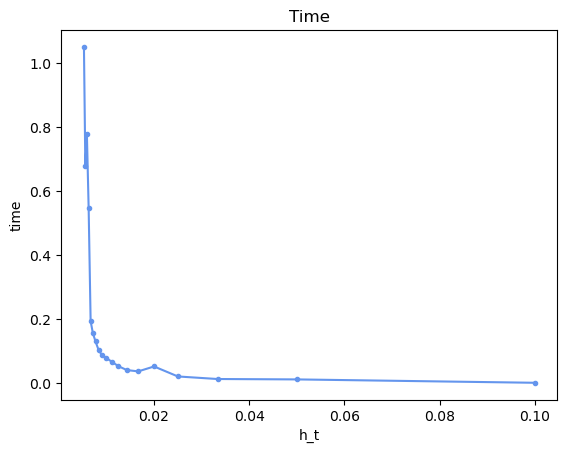

In [24]:

# Experiment in h_t direction
HT = np.array([1/i for i in range(10,200,10)])
h_x, h_y = 1/100, 1/100
norms = np.array([convergence_experiment(h_t,h_t,h_t) for h_t in HT])

plt.loglog(HT, norms[:,0], '.-', color = 'cornflowerblue', label = 'Norm for t = 1')
plt.loglog(HT, HT, '.-', color = 'hotpink', label = 'h_t')
plt.xlabel('h_t')
plt.ylabel('norm')
plt.title('Convergence in h_t')
plt.legend()
plt.show()

plt.plot(HT, norms[:,1], '.-', color = 'cornflowerblue')
plt.xlabel('h_t')
plt.ylabel('time')
plt.title('Time')
plt.show()

 <video src="solution.mp4" controls>